<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [4]:
!pip install pandas

In [5]:
!pip install matplotlib

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [6]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-02-17 17:33:15--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  47.5MB/s    in 3.5s    

2026-02-17 17:33:19 (43.4 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



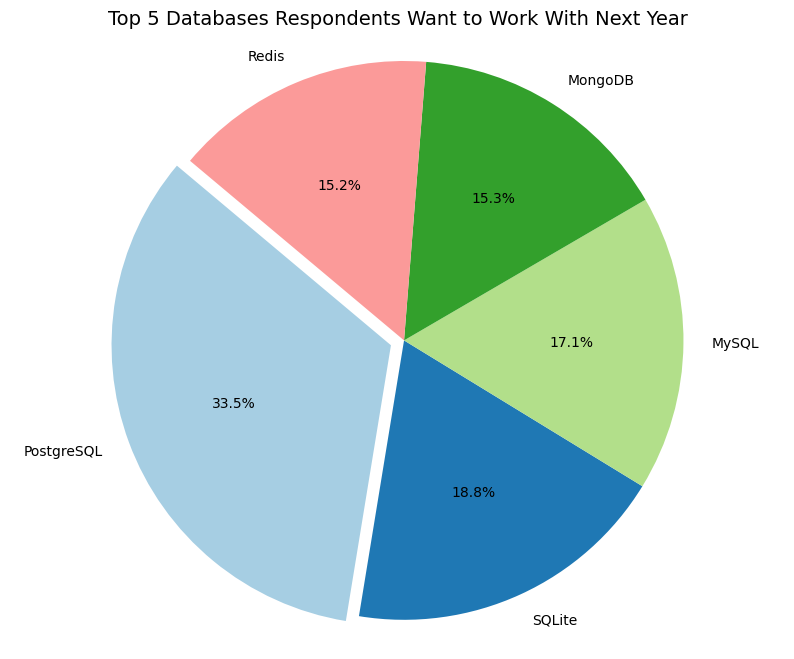

In [5]:
##Write your code here
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-data.sqlite')

query = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
df = pd.read_sql_query(query, conn)

db_series = df['DatabaseWantToWorkWith'].str.split(';').explode()

top_5_dbs = db_series.value_counts().head(5)

plt.figure(figsize=(10, 8))

plt.pie(top_5_dbs, 
        labels=top_5_dbs.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Paired.colors,
        explode=(0.05, 0, 0, 0, 0))

plt.title('Top 5 Databases Respondents Want to Work With Next Year', fontsize=14)
plt.axis('equal')  # Ensures the pie is drawn as a circle

plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



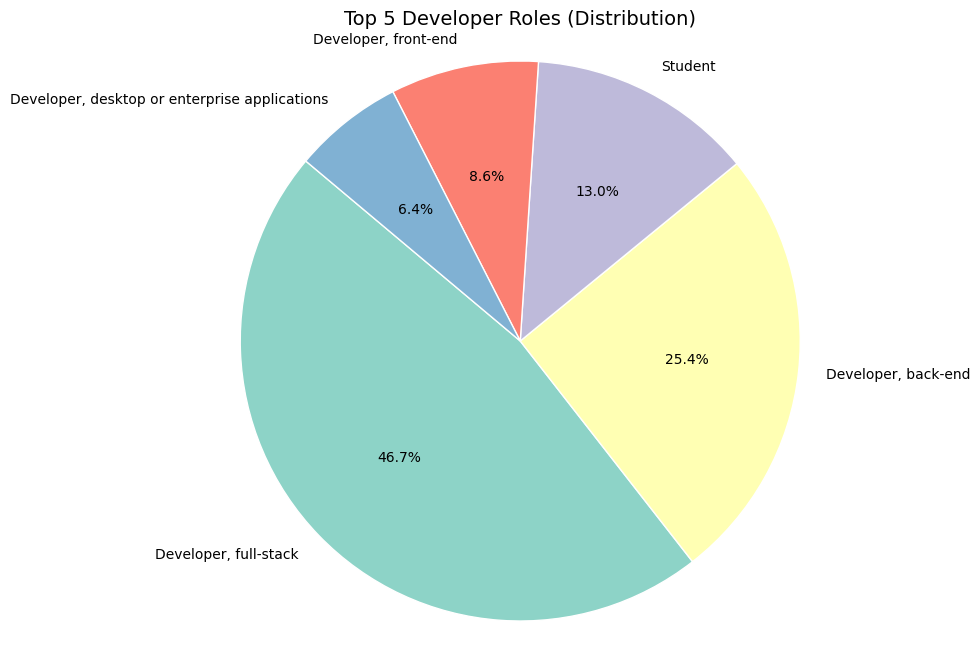

In [7]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-data.sqlite')

query = "SELECT DevType FROM main WHERE DevType IS NOT NULL"
df = pd.read_sql_query(query, conn)

dev_series = df['DevType'].str.split(';').explode()

top_5_dev = dev_series.value_counts().head(5)


plt.figure(figsize=(10, 8))

plt.pie(top_5_dev, 
        labels=top_5_dev.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Set3.colors,
        wedgeprops={'edgecolor': 'white'})

plt.title('Top 5 Developer Roles (Distribution)', fontsize=14)
plt.axis('equal') 

plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



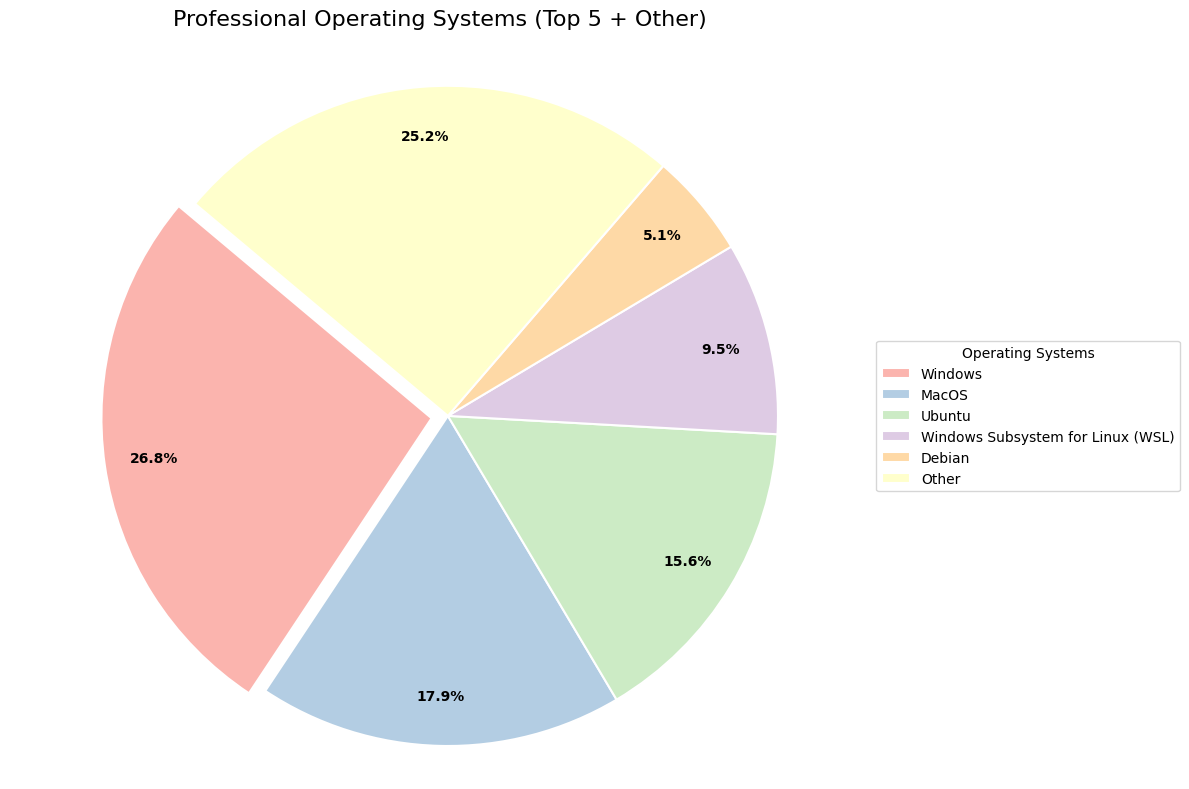

In [11]:
##Write your code here
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-data.sqlite')

query = 'SELECT "OpSysProfessional use" FROM main WHERE "OpSysProfessional use" IS NOT NULL'
df = pd.read_sql_query(query, conn)

opsys_series = df['OpSysProfessional use'].str.split(';').explode()
opsys_counts = opsys_series.value_counts()

top_n = 5
main_categories = opsys_counts.head(top_n)
other_categories_sum = opsys_counts.iloc[top_n:].sum()

final_counts = pd.concat([main_categories, pd.Series({'Other': other_categories_sum})])

plt.figure(figsize=(12, 8))

wedges, texts, autotexts = plt.pie(
    final_counts, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Pastel1.colors,
    pctdistance=0.85,
    explode=[0.05 if i == 0 else 0 for i in range(len(final_counts))],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.setp(autotexts, size=10, weight="bold")

plt.legend(wedges, final_counts.index, 
           title="Operating Systems", 
           loc="center left", 
           bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Professional Operating Systems (Top 5 + Other)', fontsize=16, pad=20)
plt.axis('equal') 
plt.tight_layout()

plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



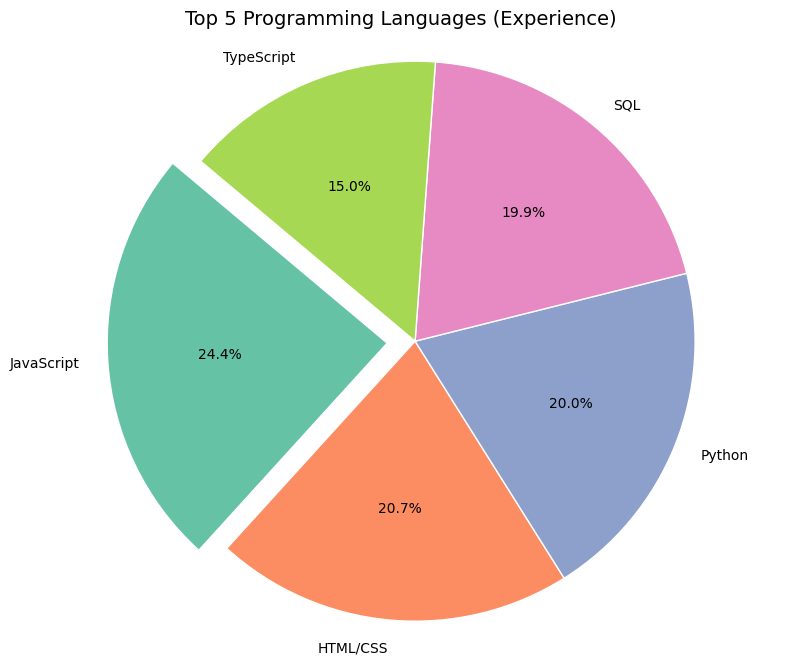

In [12]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-data.sqlite')

query = "SELECT LanguageHaveWorkedWith FROM main WHERE LanguageHaveWorkedWith IS NOT NULL"
df = pd.read_sql_query(query, conn)

lang_series = df['LanguageHaveWorkedWith'].str.split(';').explode()

top_5_langs = lang_series.value_counts().head(5)

plt.figure(figsize=(10, 8))

plt.pie(top_5_langs, 
        labels=top_5_langs.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Set2.colors,
        explode=(0.1, 0, 0, 0, 0), # Explode the #1 language for emphasis
        wedgeprops={'edgecolor': 'white'})

plt.title('Top 5 Programming Languages (Experience)', fontsize=14)
plt.axis('equal') 

plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



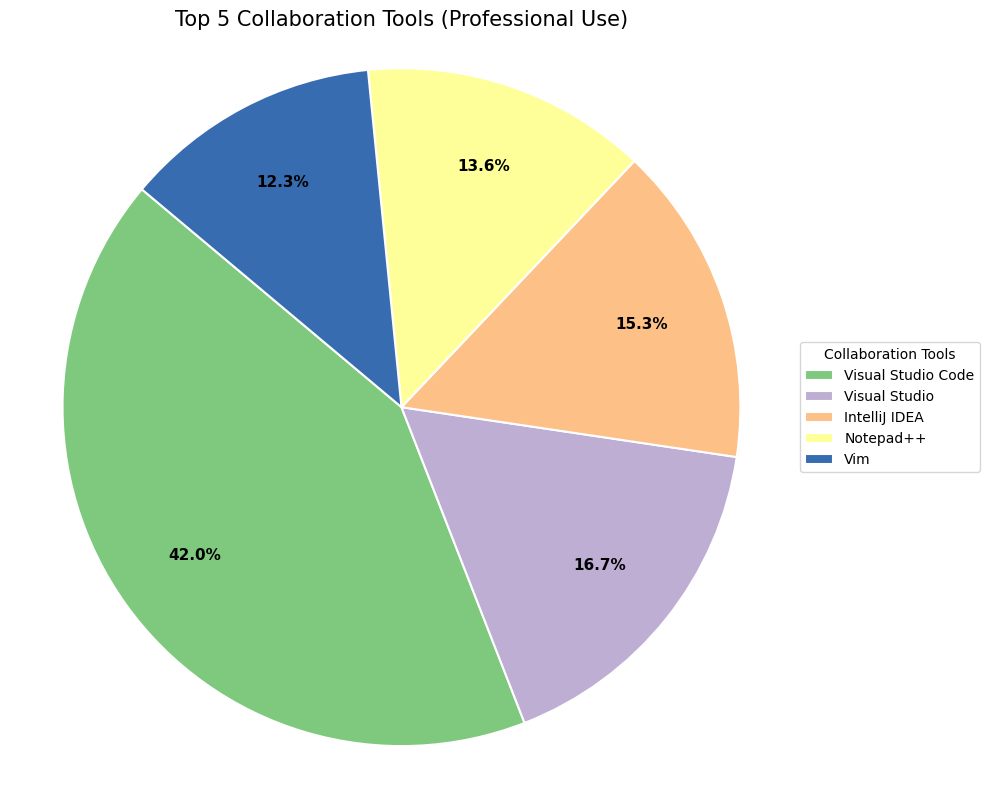

In [13]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-data.sqlite')

query = "SELECT NEWCollabToolsHaveWorkedWith FROM main WHERE NEWCollabToolsHaveWorkedWith IS NOT NULL"
df = pd.read_sql_query(query, conn)

tools_series = df['NEWCollabToolsHaveWorkedWith'].str.split(';').explode()

top_5_tools = tools_series.value_counts().head(5)

plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(
    top_5_tools, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Accent.colors,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.setp(autotexts, size=11, weight="bold")

plt.legend(wedges, top_5_tools.index, 
           title="Collaboration Tools", 
           loc="center left", 
           bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Top 5 Collaboration Tools (Professional Use)', fontsize=15)
plt.axis('equal') 
plt.tight_layout()

plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



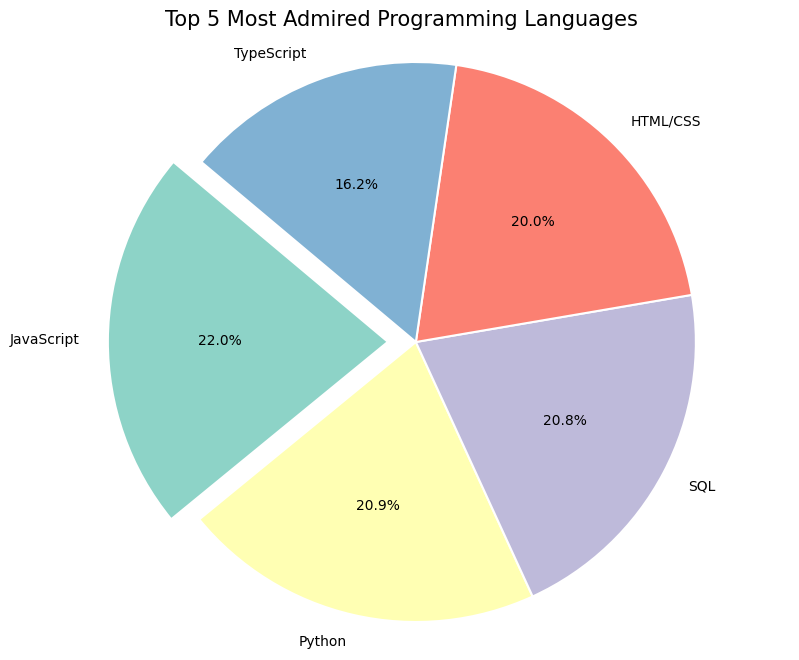

In [15]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


conn = sqlite3.connect('survey-data.sqlite')

query = "SELECT LanguageAdmired FROM main WHERE LanguageAdmired IS NOT NULL"
df = pd.read_sql_query(query, conn)

admired_series = df['LanguageAdmired'].str.split(';').explode()

top_5_admired = admired_series.value_counts().head(5)

plt.figure(figsize=(10, 8))

colors = plt.cm.Set3.colors

plt.pie(top_5_admired, 
        labels=top_5_admired.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        explode=(0.1, 0, 0, 0, 0),  # Explode the top slice for visual emphasis
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('Top 5 Most Admired Programming Languages', fontsize=15)
plt.axis('equal') 

plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



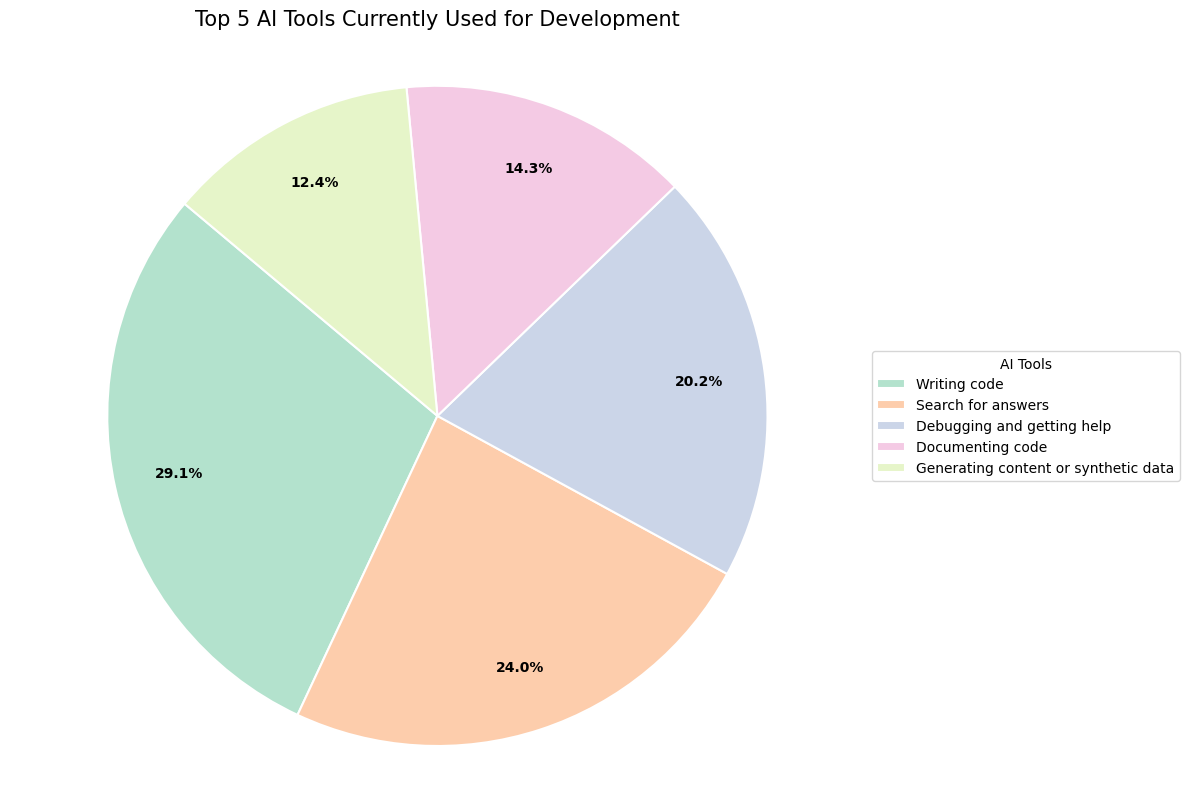

In [17]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-data.sqlite')

query = 'SELECT "AIToolCurrently Using" FROM main WHERE "AIToolCurrently Using" IS NOT NULL'
df = pd.read_sql_query(query, conn)

ai_tools_series = df['AIToolCurrently Using'].str.split(';').explode()

top_5_ai_tools = ai_tools_series.value_counts().head(5)

plt.figure(figsize=(12, 8))
wedges, texts, autotexts = plt.pie(
    top_5_ai_tools, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Pastel2.colors,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.setp(autotexts, size=10, weight="bold")

plt.legend(wedges, top_5_ai_tools.index, 
           title="AI Tools", 
           loc="center left", 
           bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Top 5 AI Tools Currently Used for Development', fontsize=15, pad=20)
plt.axis('equal') 
plt.tight_layout()

plt.show()

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



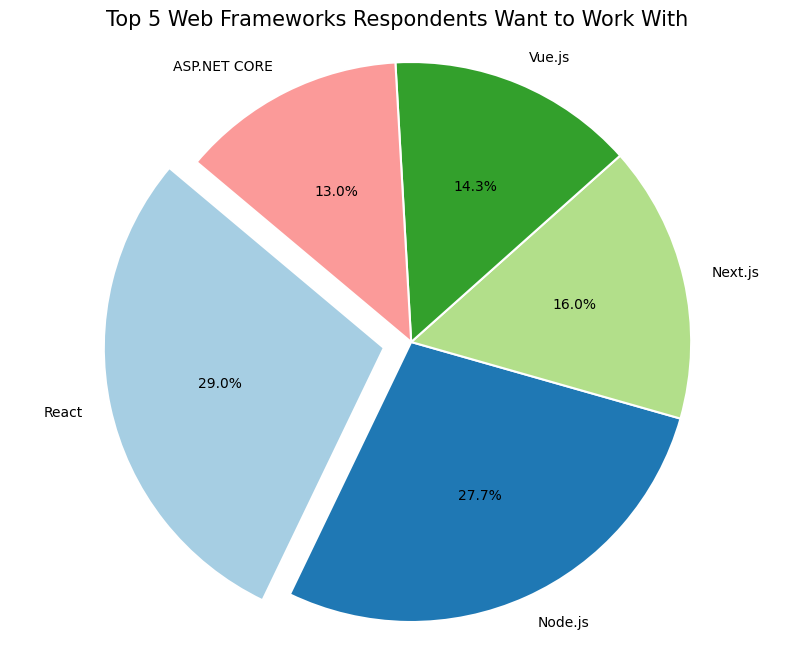

In [18]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


conn = sqlite3.connect('survey-data.sqlite')

query = "SELECT WebframeWantToWorkWith FROM main WHERE WebframeWantToWorkWith IS NOT NULL"
df = pd.read_sql_query(query, conn)

frameworks_series = df['WebframeWantToWorkWith'].str.split(';').explode()

top_5_frameworks = frameworks_series.value_counts().head(5)

plt.figure(figsize=(10, 8))

colors = plt.cm.Paired.colors

plt.pie(
    top_5_frameworks, 
    labels=top_5_frameworks.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    explode=(0.1, 0, 0, 0, 0),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Top 5 Web Frameworks Respondents Want to Work With', fontsize=15)
plt.axis('equal') 

plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



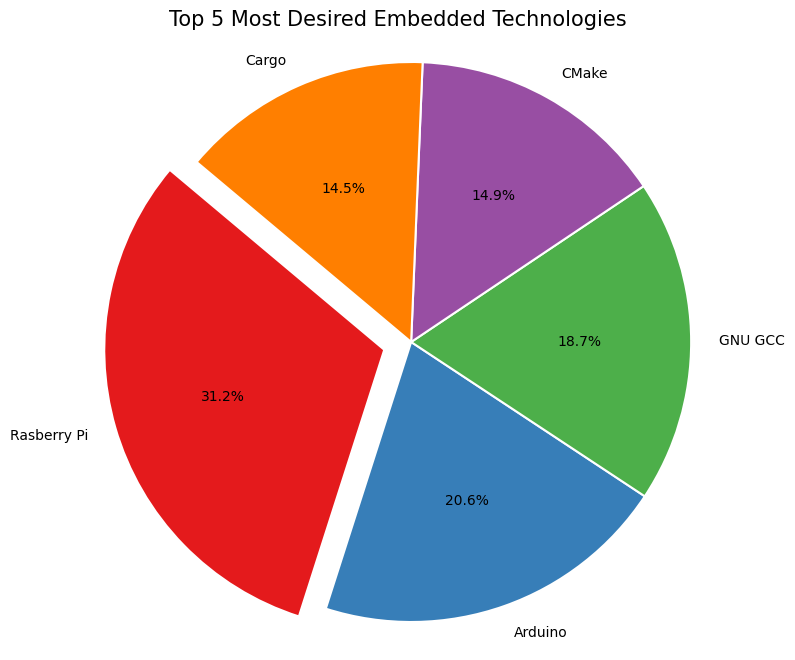

In [19]:
##Write your code here

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-data.sqlite')

query = "SELECT EmbeddedWantToWorkWith FROM main WHERE EmbeddedWantToWorkWith IS NOT NULL"
df = pd.read_sql_query(query, conn)

embedded_series = df['EmbeddedWantToWorkWith'].str.split(';').explode()

top_5_embedded = embedded_series.value_counts().head(5)

plt.figure(figsize=(10, 8))

colors = plt.cm.Set1.colors

plt.pie(
    top_5_embedded, 
    labels=top_5_embedded.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    explode=(0.1, 0, 0, 0, 0),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Top 5 Most Desired Embedded Technologies', fontsize=15)
plt.axis('equal') 

plt.show()

conn.close()

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
